In [3]:
from collections import Counter
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [4]:
def euclidean_distance(point1, point2):
    """Calculate the Euclidean distance between two points."""
    # Return the distance between the two input data points.
    return np.sqrt(np.sum((point1 - point2)**2))

In [5]:
def knn_classifier(train_data, train_labels, test_data, k=3):
    """Simple k-NN classifier."""
    predictions = []

    for test_point in test_data:
        # Calculate distances from the current test point to all training points
        distances = [euclidean_distance(test_point, train_point) for train_point in train_data]

        # Get the indices of the k nearest neighbors
        k_indices = np.argsort(distances)[:k]

        # Get the labels of the k nearest neighbors
        k_nearest_labels = []

        for index in k_indices:
          k_nearest_labels.append(int(train_labels[index]))

        # Determine the most common label among the k nearest neighbors
        most_common_label = Counter(k_nearest_labels).most_common(1)[0][0]

        # Append the predicted label to the predictions list
        predictions.append(most_common_label)

    return np.array(predictions)

The accuracy of the knn classifier is 0.9970845481049563 when k=1
The accuracy of the knn classifier is 0.9985422740524781 when k=3
The accuracy of the knn classifier is 0.9956268221574344 when k=5
The accuracy of the knn classifier is 0.9985422740524781 when k=7


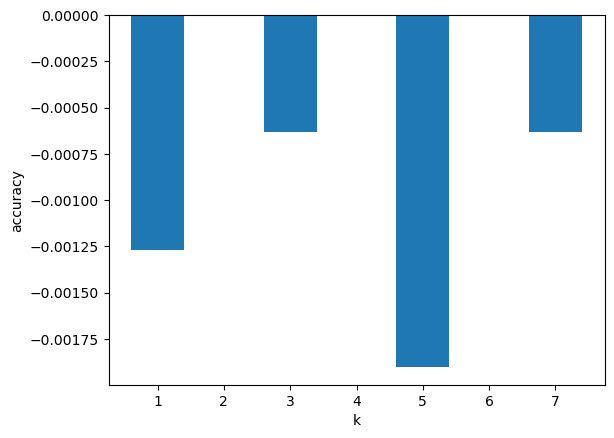

In [6]:
df = pd.read_csv('./banknotes_new.csv')
X, y = df.drop('Class', axis=1),  df['Class']

# Conduct training data and test data split randomly with a 50:50 ratio, setting random_state=2025
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=2025)

y_train = y_train.values
y_test = y_test.values

# Standardise the value of each feature in the dataset.

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Loads all k-factors to test into array to loop through
# Also initialises accuracy array for later purposes
accs = []
kfacs = [1,3,5,7]

for n in kfacs:
  k = n
  test_label = knn_classifier(X_train, y_train, X_test, k=k)

# Calculate and print the accuracy of the knn classifier on the test dataset.
  accuracy = 1.0-np.sum(np.abs(y_test - test_label))/y_test.shape[0]
  accs.append(accuracy)
  print(f'The accuracy of the knn classifier is {accuracy} when k={k}')

# Visual difference between accuracy scores. 
# Log scaled, k=5 has the lowest accuracy
accs = np.log10(accs)
plt.bar(kfacs, accs)
plt.xlabel('k')
plt.ylabel('accuracy')
plt.show()